# Robust validation of the EPS-revision and news-sentiment signal

## Research question

The original hypothesis was that analyst EPS revisions are relatively informed, while news sentiment is noisier and more prone to temporary overreaction. The strategy therefore looks for disagreement:

- **Long:** strongly positive three-month EPS revisions accompanied by negative recent news sentiment.
- **Short:** strongly negative three-month EPS revisions accompanied by positive recent news sentiment.

This notebook is a cleaned and reproducible version of the original analysis. It deliberately **does not search for new signals or tune many alternatives**.

### Main improvements

- Uses only the three-month EPS revision signal.
- Deduplicates repeated price and news records.
- Uses news published strictly before the portfolio date.
- Calculates a genuine one-month forward return using explicit entry and exit dates.
- Uses independent EPS and sentiment quintiles rather than sparse nested deciles.
- Builds an equal-weighted, sector-neutral portfolio with net exposure zero and gross exposure one.
- Reports turnover, transaction costs, long and short legs, a return-shuffling test, and a block bootstrap.

## 1. Imports and fixed assumptions

All material choices are kept in one place. They should be fixed before examining the final full-database results.

In [3]:
from pathlib import Path
import warnings

import duckdb
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [4]:
# Change this to Path("research.duckdb") when running against the full database.
DB_PATH = Path("research.duckdb")
PANEL_CACHE = Path("cache/monthly_research_panel.parquet")

# Change this to True whenever you want to rebuild the panel in section 3
REBUILD_PANEL = True

# The sample begins later, but the same notebook can use the full historical period.
START_DATE = "2014-12-01"
END_DATE = "2025-12-01"

MIN_MARKET_CAP = 500.0       # Source-data units, matching the original notebook.
MIN_ANALYSTS = 3
MAX_ABS_REVISION = 1.0       # Remove revisions above 100% in absolute value.
EPS_DENOMINATOR_FLOOR = 1e-6
PRICE_WINDOW_DAYS = 10       # Maximum delay allowed when locating an entry/exit close.
SENTIMENT_WINDOW_DAYS = 30

N_EPS_DECILES = 10
N_PORTFOLIO_QUANTILES = 5
MIN_SECTOR_GROUP_SIZE = 10
TRANSACTION_COST_BPS = 10    # Cost per unit of portfolio turnover.

N_PERMUTATIONS = 200
N_BOOTSTRAPS = 1_000
BOOTSTRAP_BLOCK_MONTHS = 6
RANDOM_SEED = 42

# This fallback allows the uploaded sample to run in ChatGPT's environment.
if not DB_PATH.exists():
    uploaded_path = Path("/mnt/data") / DB_PATH.name
    if uploaded_path.exists():
        DB_PATH = uploaded_path

if not DB_PATH.exists():
    raise FileNotFoundError(
        f"Database not found at {DB_PATH}. Change DB_PATH to the location of your DuckDB file."
    )

print(f"Database: {DB_PATH.resolve()}")

Database: C:\Users\adamf\PycharmProjects\FedContracts_AlgoTrading\research.duckdb


## 2. Source-data checks

These checks make the assumptions visible before any signal is calculated. Company names are retained for presentation only; all joins use `IQID`.

In [5]:
con = duckdb.connect(str(DB_PATH), read_only=True)

tables = con.execute("SHOW TABLES").fetchdf()["name"].tolist()
required_tables = {"master_historical_eps", "master_historical_prices", "sentiment"}
missing_tables = required_tables.difference(tables)
if missing_tables:
    raise ValueError(f"Missing required tables: {sorted(missing_tables)}")

source_summary = con.execute("""
    SELECT
        'master_historical_eps' AS table_name,
        COUNT(*) AS rows,
        COUNT(DISTINCT IQID) AS iqids,
        MIN(AS_OF)::VARCHAR AS first_date,
        MAX(AS_OF)::VARCHAR AS last_date
    FROM master_historical_eps
    UNION ALL
    SELECT
        'master_historical_prices',
        COUNT(*),
        COUNT(DISTINCT IQID),
        MIN(AS_OF)::VARCHAR,
        MAX(AS_OF)::VARCHAR
    FROM master_historical_prices
    UNION ALL
    SELECT
        'sentiment',
        COUNT(*),
        COUNT(DISTINCT CAST(iqid AS BIGINT)),
        MIN(CAST(dev_date AS DATE))::VARCHAR,
        MAX(CAST(dev_date AS DATE))::VARCHAR
    FROM sentiment
""").fetchdf()

duplicate_checks = con.execute("""
    WITH eps_duplicates AS (
        SELECT IQID, AS_OF, COUNT(*) AS n
        FROM master_historical_eps
        GROUP BY IQID, AS_OF
        HAVING COUNT(*) > 1
    ),
    price_duplicates AS (
        SELECT
            IQID,
            AS_OF,
            COUNT(*) AS n,
            COUNT(DISTINCT adj_close) AS distinct_prices,
            COUNT(DISTINCT volume) AS distinct_volumes
        FROM master_historical_prices
        GROUP BY IQID, AS_OF
        HAVING COUNT(*) > 1
    ),
    news_duplicates AS (
        SELECT CAST(iqid AS BIGINT) AS IQID, CAST(dev_date AS DATE) AS dev_date,
               text_input, COUNT(*) AS n
        FROM sentiment
        GROUP BY 1, 2, 3
        HAVING COUNT(*) > 1
    )
    SELECT
        (SELECT COUNT(*) FROM eps_duplicates) AS duplicate_eps_keys,
        (SELECT COUNT(*) FROM price_duplicates) AS duplicate_price_keys,
        (SELECT COUNT(*) FROM price_duplicates
          WHERE distinct_prices > 1 OR distinct_volumes > 1) AS conflicting_price_keys,
        (SELECT COUNT(*) FROM news_duplicates) AS duplicate_news_keys,
        (SELECT COUNT(*) FROM sentiment
          WHERE TRY_CAST(sentiment AS DOUBLE) IS NULL) AS non_numeric_sentiment_rows
""").fetchdf()

display(source_summary)
display(duplicate_checks)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,table_name,rows,iqids,first_date,last_date
0,master_historical_eps,1042083,7497,2014-09-01,2026-03-01
1,master_historical_prices,22618449,7433,2014-03-03,2026-02-27
2,sentiment,786068,3956,2014-01-09,2026-12-03


,duplicate_eps_keys,duplicate_price_keys,conflicting_price_keys,duplicate_news_keys,non_numeric_sentiment_rows
0,0,200000,0,26362,0


Exact duplicate prices are collapsed to one observation. Repeated identical news records are collapsed by `(IQID, date, text)` and their nearly identical floating-point scores are averaged.

## 3. Build the monthly research panel

For each stock and monthly `AS_OF` date:

1. The three-month revision is calculated relative to the EPS estimate exactly three months earlier.
2. The revision is standardized relative to other eligible firms in the same sector and month.
3. Thirty-day sentiment is the mean score of deduplicated news from the preceding 30 days. News on the formation date itself is excluded.
4. Entry is the first valid close on or after `AS_OF`.
5. Exit is the first valid close on or after the next month's `AS_OF`.

This avoids using `LEAD` on an irregular sequence of observations and makes the holding period explicit.

In [6]:
if PANEL_CACHE.exists() and not REBUILD_PANEL:
    print(f"Loading cached research panel from {PANEL_CACHE}...")
    panel = pd.read_parquet(PANEL_CACHE)

else:
    print("Building monthly research panel from DuckDB...")
    panel_query = f"""
    WITH prices_clean AS (
        -- Duplicate price rows in the source have identical values; averaging removes them deterministically.
        SELECT
            IQID,
            AS_OF,
            AVG(adj_close) AS adj_close,
            AVG(volume) AS volume
        FROM master_historical_prices
        WHERE adj_close IS NOT NULL
        AND adj_close > 0
        GROUP BY IQID, AS_OF
    ),
    sentiment_deduplicated AS (
        SELECT
            CAST(iqid AS BIGINT) AS IQID,
            CAST(dev_date AS DATE) AS dev_date,
            text_input,
            AVG(TRY_CAST(sentiment AS DOUBLE)) AS sentiment
        FROM sentiment
        WHERE TRY_CAST(sentiment AS DOUBLE) IS NOT NULL
        GROUP BY 1, 2, 3
    ),
    eps_with_lag AS (
        SELECT
            current_eps.AS_OF,
            current_eps.IQID,
            current_eps.company_name,
            current_eps.exchange,
            current_eps.sector,
            current_eps.marketcap,
            current_eps.num_est,
            current_eps.eps_est,
            lagged_eps.eps_est AS eps_est_3m
        FROM master_historical_eps AS current_eps
        LEFT JOIN master_historical_eps AS lagged_eps
        ON current_eps.IQID = lagged_eps.IQID
        AND lagged_eps.AS_OF = CAST(current_eps.AS_OF - INTERVAL '3 months' AS DATE)
        WHERE current_eps.AS_OF BETWEEN DATE '{START_DATE}' AND DATE '{END_DATE}'
    ),
    eligible_eps AS (
        SELECT
            *,
            (eps_est - eps_est_3m) / ABS(eps_est_3m) AS rev_3m
        FROM eps_with_lag
        WHERE sector IS NOT NULL
        AND marketcap >= {MIN_MARKET_CAP}
        AND num_est >= {MIN_ANALYSTS}
        AND eps_est IS NOT NULL
        AND eps_est_3m IS NOT NULL
        AND ABS(eps_est_3m) >= {EPS_DENOMINATOR_FLOOR}
    ),
    eps_scored AS (
        SELECT
            *,
            (rev_3m - AVG(rev_3m) OVER (PARTITION BY AS_OF, sector)) /
            NULLIF(STDDEV_POP(rev_3m) OVER (PARTITION BY AS_OF, sector), 0) AS z_3m
        FROM eligible_eps
        WHERE ABS(rev_3m) <= {MAX_ABS_REVISION}
    ),
    monthly_sentiment AS (
        SELECT
            e.AS_OF,
            e.IQID,
            AVG(s.sentiment) AS sent_30d,
            COUNT(s.sentiment) AS news_count_30d
        FROM eps_scored AS e
        LEFT JOIN sentiment_deduplicated AS s
        ON e.IQID = s.IQID
        AND s.dev_date >= CAST(e.AS_OF - INTERVAL '{SENTIMENT_WINDOW_DAYS} days' AS DATE)
        AND s.dev_date < e.AS_OF
        GROUP BY e.AS_OF, e.IQID
    ),
    fully_scored AS (
        SELECT
            e.*,
            m.sent_30d,
            m.news_count_30d,
            (m.sent_30d - AVG(m.sent_30d) OVER (PARTITION BY e.AS_OF, e.sector)) /
            NULLIF(STDDEV_POP(m.sent_30d) OVER (PARTITION BY e.AS_OF, e.sector), 0)
                AS z_sent_30d
        FROM eps_scored AS e
        JOIN monthly_sentiment AS m USING (AS_OF, IQID)
    ),
    entry_dates AS (
        SELECT
            e.AS_OF,
            e.IQID,
            MIN(p.AS_OF) AS entry_date
        FROM fully_scored AS e
        JOIN prices_clean AS p
        ON e.IQID = p.IQID
        AND p.AS_OF >= e.AS_OF
        AND p.AS_OF <= CAST(e.AS_OF + INTERVAL '{PRICE_WINDOW_DAYS} days' AS DATE)
        GROUP BY e.AS_OF, e.IQID
    ),
    exit_dates AS (
        SELECT
            e.AS_OF,
            e.IQID,
            MIN(p.AS_OF) AS exit_date
        FROM fully_scored AS e
        JOIN prices_clean AS p
        ON e.IQID = p.IQID
        AND p.AS_OF >= CAST(e.AS_OF + INTERVAL '1 month' AS DATE)
        AND p.AS_OF <= CAST(
            e.AS_OF + INTERVAL '1 month' + INTERVAL '{PRICE_WINDOW_DAYS} days' AS DATE
        )
        GROUP BY e.AS_OF, e.IQID
    )
    SELECT
        e.*,
        entry.entry_date,
        entry_price.adj_close AS entry_price,
        exit.exit_date,
        exit_price.adj_close AS exit_price,
        exit_price.adj_close / entry_price.adj_close - 1 AS fwd_1m
    FROM fully_scored AS e
    JOIN entry_dates AS entry USING (AS_OF, IQID)
    JOIN exit_dates AS exit USING (AS_OF, IQID)
    JOIN prices_clean AS entry_price
    ON entry_price.IQID = e.IQID
    AND entry_price.AS_OF = entry.entry_date
    JOIN prices_clean AS exit_price
    ON exit_price.IQID = e.IQID
    AND exit_price.AS_OF = exit.exit_date
    ORDER BY e.AS_OF, e.sector, e.IQID
    """

    panel = con.execute(panel_query).fetchdf()
    con.close()

    for column in ["AS_OF", "entry_date", "exit_date"]:
        panel[column] = pd.to_datetime(panel[column])

    panel["entry_delay_days"] = (panel["entry_date"] - panel["AS_OF"]).dt.days
    panel["exit_target"] = panel["AS_OF"] + pd.DateOffset(months=1)
    panel["exit_delay_days"] = (panel["exit_date"] - panel["exit_target"]).dt.days

    PANEL_CACHE.parent.mkdir(parents=True, exist_ok=True)
    panel.to_parquet(PANEL_CACHE, index=False)

    print(f"Research panel saved to {PANEL_CACHE}")

Building monthly research panel from DuckDB...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Research panel saved to cache\monthly_research_panel.parquet


In [7]:
# Critical correctness checks. The notebook stops here if any fail.
assert not panel.empty, "The research panel is empty. Check the dates and filters."
assert not panel.duplicated(["AS_OF", "IQID"]).any(), "Duplicate stock-month observations remain."
assert panel["entry_price"].gt(0).all() and panel["exit_price"].gt(0).all()
assert panel["entry_delay_days"].between(0, PRICE_WINDOW_DAYS).all()
assert panel["exit_delay_days"].between(0, PRICE_WINDOW_DAYS).all()
assert np.isfinite(panel["fwd_1m"]).all()

coverage_summary = pd.DataFrame({
    "Measure": [
        "Stock-month observations",
        "Distinct companies",
        "Distinct months",
        "First formation month",
        "Last formation month",
        "Observations with recent news",
        "Maximum entry delay (days)",
        "Maximum exit delay (days)",
    ],
    "Value": [
        f"{len(panel):,}",
        f"{panel['IQID'].nunique():,}",
        f"{panel['AS_OF'].nunique():,}",
        panel["AS_OF"].min().date(),
        panel["AS_OF"].max().date(),
        f"{panel['sent_30d'].notna().mean():.1%}",
        int(panel["entry_delay_days"].max()),
        int(panel["exit_delay_days"].max()),
    ]
})

display(coverage_summary)
display(panel.head())

,Measure,Value
0,Stock-month observations,"213,088"
1,Distinct companies,"2,755"
2,Distinct months,133
3,First formation month,2014-12-01
4,Last formation month,2025-12-01
5,Observations with recent news,68.1%
6,Maximum entry delay (days),4
7,Maximum exit delay (days),3


,AS_OF,IQID,company_name,exchange,sector,marketcap,num_est,eps_est,eps_est_3m,rev_3m,z_3m,sent_30d,news_count_30d,z_sent_30d,entry_date,entry_price,exit_date,exit_price,fwd_1m,entry_delay_days,exit_target,exit_delay_days
0,2014-12-01,4018931,Shenandoah Telecommunications Company (NASDAQG...,NASDAQGS,Communication Services,696.3900,3,0.7100,0.6800,0.0441,0.2130,NaN,0,NaN,2014-12-01,8.4200,2015-01-02,9.1500,0.0867,0,2015-01-01,1
1,2014-12-01,4024242,AT&T Inc. (NYSE:T),NYSE,Communication Services,"181,856.2188",30,2.5500,2.6000,-0.0192,-0.0829,-0.6714,14,-0.5079,2014-12-01,13.7400,2015-01-02,13.2700,-0.0342,0,2015-01-01,1
2,2014-12-01,4057179,"Lumen Technologies, Inc. (NYSE:LUMN)",NYSE,Communication Services,"23,455.9902",14,2.6300,2.6500,-0.0075,-0.0283,-0.6000,2,-0.2863,2014-12-01,20.5900,2015-01-02,19.8300,-0.0369,0,2015-01-01,1
3,2014-12-01,4057180,Comcast Corporation (NASDAQGS:CMCSA),NASDAQGS,Communication Services,"169,266.4844",20,1.4800,1.4600,0.0137,0.0709,-0.5502,6,-0.1319,2014-12-01,20.3400,2015-01-02,20.6100,0.0133,0,2015-01-01,1
4,2014-12-01,4057227,"Array Digital Infrastructure, Inc. (NYSE:AD)",NYSE,Communication Services,"3,240.2400",6,-1.1400,-1.3000,0.1231,0.5819,-0.0459,5,1.4326,2014-12-01,22.2800,2015-01-02,23.0400,0.0341,0,2015-01-01,1


## 4. Helper functions

Quantile groups are calculated independently within each month and sector. A minimum group size prevents unstable buckets in very small sector-month samples.

In [8]:
def add_quantile_bucket(
    data,
    value_column,
    n_quantiles,
    output_column,
    min_group_size=MIN_SECTOR_GROUP_SIZE,
):
    """Assign deterministic within-month, within-sector quantile buckets."""
    result = data.sort_values(["AS_OF", "sector", "IQID"]).copy()
    grouped = result.groupby(["AS_OF", "sector"], sort=False)[value_column]
    group_size = grouped.transform("count")
    percentile_rank = grouped.rank(method="average", pct=True)
    bucket = np.floor(percentile_rank * n_quantiles - 1e-12).clip(0, n_quantiles - 1)
    result[output_column] = bucket.where(group_size >= min_group_size).astype("Int64")
    return result


def maximum_drawdown(returns):
    wealth = (1 + returns.fillna(0)).cumprod()
    drawdown = wealth / wealth.cummax() - 1
    return drawdown.min()


def performance_statistics(returns, turnover=None):
    returns = returns.dropna()
    n_months = len(returns)
    volatility = returns.std(ddof=1)
    annualized_return = (1 + returns).prod() ** (12 / n_months) - 1
    sharpe = np.nan if volatility == 0 else returns.mean() / volatility * np.sqrt(12)

    return {
        "Months": n_months,
        "Mean monthly return": returns.mean(),
        "Annualized return": annualized_return,
        "Annualized volatility": volatility * np.sqrt(12),
        "Sharpe ratio": sharpe,
        "Maximum drawdown": maximum_drawdown(returns),
        "Positive months": (returns > 0).mean(),
        "Average turnover": np.nan if turnover is None else turnover.reindex(returns.index).mean(),
    }


def build_sector_neutral_portfolio(bucketed_data):
    """
    Select the two disagreement corners and weight each active sector neutrally.

    Every active sector receives equal gross exposure. Within a sector, half is allocated
    equally to longs and half equally to shorts. Sectors without both sides are not traded.
    """
    positions = bucketed_data.dropna(subset=["eps_q", "sent_q", "fwd_1m"]).copy()
    positions["side"] = 0
    positions.loc[
        (positions["eps_q"] == N_PORTFOLIO_QUANTILES - 1)
        & (positions["sent_q"] == 0),
        "side",
    ] = 1
    positions.loc[
        (positions["eps_q"] == 0)
        & (positions["sent_q"] == N_PORTFOLIO_QUANTILES - 1),
        "side",
    ] = -1
    positions = positions[positions["side"] != 0].copy()

    side_counts = positions.groupby(["AS_OF", "sector", "side"]).size().unstack(fill_value=0)
    if 1 not in side_counts.columns:
        side_counts[1] = 0
    if -1 not in side_counts.columns:
        side_counts[-1] = 0

    active_sectors = side_counts[
        (side_counts[1] > 0) & (side_counts[-1] > 0)
    ].reset_index()[["AS_OF", "sector"]]

    positions = positions.merge(active_sectors, on=["AS_OF", "sector"], how="inner")
    positions["names_on_side"] = positions.groupby(
        ["AS_OF", "sector", "side"]
    )["IQID"].transform("count")

    sectors_per_month = active_sectors.groupby("AS_OF")["sector"].nunique()
    positions["active_sectors"] = positions["AS_OF"].map(sectors_per_month)
    positions["weight"] = (
        positions["side"]
        * (0.5 / positions["active_sectors"])
        / positions["names_on_side"]
    )
    return positions

## 5. EPS revisions on their own

This reproduces the original decile-style diagnostic without news sentiment. Returns are first averaged within each month and decile, then averaged through time so months with more observations do not automatically receive more weight.

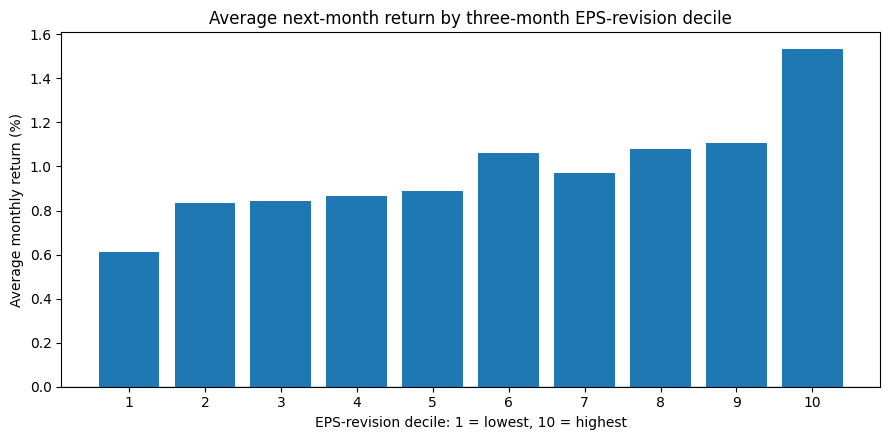

Average top-minus-bottom decile spread: 0.92% per month
Positive spread months: 68.4%


In [9]:
eps_analysis = panel.dropna(subset=["z_3m", "fwd_1m"]).copy()
eps_analysis = add_quantile_bucket(
    eps_analysis,
    value_column="z_3m",
    n_quantiles=N_EPS_DECILES,
    output_column="eps_decile",
)
eps_analysis = eps_analysis.dropna(subset=["eps_decile"])

eps_analysis["eps_decile"] = eps_analysis["eps_decile"].astype(int)
monthly_decile_returns = (
    eps_analysis.groupby(["AS_OF", "eps_decile"])["fwd_1m"]
    .mean()
    .rename("return")
    .reset_index()
)
eps_decile_returns = monthly_decile_returns.groupby("eps_decile")["return"].mean()

monthly_spread = (
    monthly_decile_returns.pivot(index="AS_OF", columns="eps_decile", values="return")
)
monthly_spread = monthly_spread[N_EPS_DECILES - 1] - monthly_spread[0]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(eps_decile_returns.index + 1, eps_decile_returns.values * 100)
ax.axhline(0, linewidth=1)
ax.set_title("Average next-month return by three-month EPS-revision decile")
ax.set_xlabel("EPS-revision decile: 1 = lowest, 10 = highest")
ax.set_ylabel("Average monthly return (%)")
ax.set_xticks(range(1, N_EPS_DECILES + 1))
plt.tight_layout()
plt.show()

print(f"Average top-minus-bottom decile spread: {monthly_spread.mean():.2%} per month")
print(f"Positive spread months: {(monthly_spread > 0).mean():.1%}")

## 6. Joint EPS-revision and sentiment relationship

EPS and sentiment quintiles are assigned **independently** within each sector and month. This keeps the original disagreement idea but avoids splitting each small sector-month into as many as 100 nested cells.

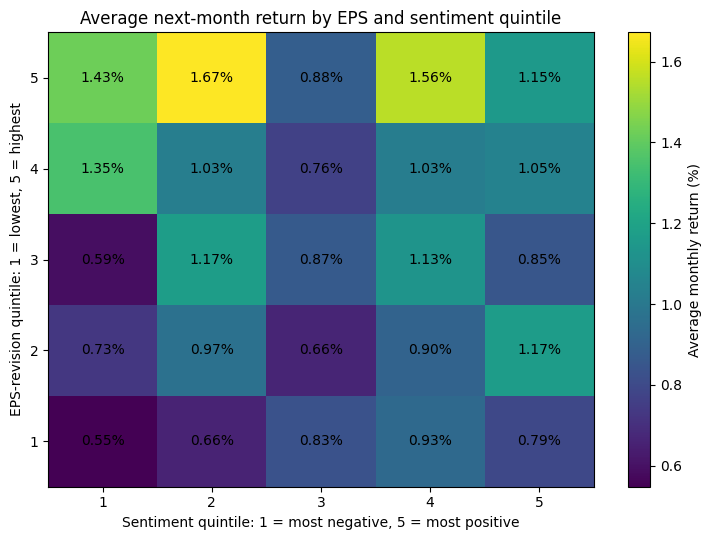

High-EPS / negative-sentiment cell: 1.43%
Low-EPS / positive-sentiment stock return: 0.79%
Simple corner spread: 0.63%


In [10]:
combined = panel.dropna(subset=["z_3m", "z_sent_30d", "fwd_1m"]).copy()
combined = add_quantile_bucket(
    combined, "z_3m", N_PORTFOLIO_QUANTILES, "eps_q"
)
combined = add_quantile_bucket(
    combined, "z_sent_30d", N_PORTFOLIO_QUANTILES, "sent_q"
)
combined = combined.dropna(subset=["eps_q", "sent_q"]).copy()
combined[["eps_q", "sent_q"]] = combined[["eps_q", "sent_q"]].astype(int)

monthly_cells = (
    combined.groupby(["AS_OF", "eps_q", "sent_q"])["fwd_1m"]
    .mean()
    .rename("return")
    .reset_index()
)
heatmap = monthly_cells.groupby(["eps_q", "sent_q"])["return"].mean().unstack()
heatmap = heatmap.reindex(
    index=range(N_PORTFOLIO_QUANTILES),
    columns=range(N_PORTFOLIO_QUANTILES),
)

fig, ax = plt.subplots(figsize=(7.5, 5.5))
image = ax.imshow(heatmap.values * 100, aspect="auto", origin="lower")
ax.set_title("Average next-month return by EPS and sentiment quintile")
ax.set_xlabel("Sentiment quintile: 1 = most negative, 5 = most positive")
ax.set_ylabel("EPS-revision quintile: 1 = lowest, 5 = highest")
ax.set_xticks(range(N_PORTFOLIO_QUANTILES), range(1, N_PORTFOLIO_QUANTILES + 1))
ax.set_yticks(range(N_PORTFOLIO_QUANTILES), range(1, N_PORTFOLIO_QUANTILES + 1))

for row in range(N_PORTFOLIO_QUANTILES):
    for column in range(N_PORTFOLIO_QUANTILES):
        value = heatmap.iloc[row, column]
        if pd.notna(value):
            ax.text(column, row, f"{value:.2%}", ha="center", va="center")

fig.colorbar(image, ax=ax, label="Average monthly return (%)")
plt.tight_layout()
plt.show()

long_corner = heatmap.loc[N_PORTFOLIO_QUANTILES - 1, 0]
short_stock_corner = heatmap.loc[0, N_PORTFOLIO_QUANTILES - 1]
print(f"High-EPS / negative-sentiment cell: {long_corner:.2%}")
print(f"Low-EPS / positive-sentiment stock return: {short_stock_corner:.2%}")
print(f"Simple corner spread: {long_corner - short_stock_corner:.2%}")

## 7. Sector-neutral portfolio construction

A sector is traded in a month only when it contains at least one valid long and one valid short. This avoids manufacturing sector neutrality by assigning weights to stocks that did not satisfy the signal.

In [21]:
portfolio = build_sector_neutral_portfolio(combined)

if portfolio.empty:
    raise ValueError(
        "No portfolio could be formed. Inspect group sizes or the chosen filters."
    )

# Portfolio accounting checks.
assert not portfolio.duplicated(["AS_OF", "IQID"]).any()
monthly_exposure = portfolio.groupby("AS_OF").agg(
    net_exposure=("weight", "sum"),
    gross_exposure=("weight", lambda values: values.abs().sum()),
)
assert monthly_exposure["net_exposure"].abs().max() < 1e-10
assert np.allclose(monthly_exposure["gross_exposure"], 1.0)
assert portfolio.groupby(["AS_OF", "sector"])["weight"].sum().abs().max() < 1e-10

all_months = pd.Index(sorted(panel["AS_OF"].unique()), name="AS_OF")
portfolio["contribution"] = portfolio["weight"] * portfolio["fwd_1m"]

monthly_returns = portfolio.groupby("AS_OF").agg(
    gross_return=("contribution", "sum"),
    positions=("IQID", "size"),
    active_sectors=("sector", "nunique"),
).reindex(all_months, fill_value=0)

long_stock_return = (
    portfolio[portfolio["weight"] > 0]
    .assign(weighted_return=lambda frame: frame["weight"] * frame["fwd_1m"])
    .groupby("AS_OF")["weighted_return"].sum() / 0.5
).rename("long_stock_return")

short_profit = (
    portfolio[portfolio["weight"] < 0]
    .assign(weighted_return=lambda frame: frame["weight"] * frame["fwd_1m"])
    .groupby("AS_OF")["weighted_return"].sum() / 0.5
).rename("short_profit")

monthly_returns = monthly_returns.join(long_stock_return).join(short_profit)
monthly_returns[["long_stock_return", "short_profit"]] = monthly_returns[
    ["long_stock_return", "short_profit"]
].fillna(0.0)

# Months without a valid portfolio are treated as cash. Reindexing also captures
# the cost of closing a portfolio before a zero-position month.
weight_matrix = portfolio.pivot_table(
    index="AS_OF", columns="IQID", values="weight", fill_value=0
).reindex(all_months, fill_value=0).sort_index()

monthly_returns["turnover"] = weight_matrix.diff().abs().sum(axis=1)
monthly_returns.iloc[0, monthly_returns.columns.get_loc("turnover")] = (
    weight_matrix.iloc[0].abs().sum()
)
monthly_returns["transaction_cost"] = (
    monthly_returns["turnover"] * TRANSACTION_COST_BPS / 10_000
)
monthly_returns["net_return"] = (
    monthly_returns["gross_return"] - monthly_returns["transaction_cost"]
)

portfolio_coverage = pd.DataFrame({
    "Measure": [
        "Research months",
        "Months with an active portfolio",
        "Average positions when active",
        "Average active sectors when active",
        "Maximum absolute net exposure",
        "Maximum gross-exposure error",
    ],
    "Value": [
        len(monthly_returns),
        int((monthly_returns["positions"] > 0).sum()),
        monthly_returns.loc[monthly_returns["positions"] > 0, "positions"].mean(),
        monthly_returns.loc[monthly_returns["positions"] > 0, "active_sectors"].mean(),
        monthly_exposure["net_exposure"].abs().max(),
        (monthly_exposure["gross_exposure"] - 1).abs().max(),
    ],
})

display(portfolio_coverage)
display(portfolio.head(10))

,Measure,Value
0,Research months,133.0000
1,Months with an active portfolio,130.0000
2,Average positions when active,70.5769
3,Average active sectors when active,7.0846
4,Maximum absolute net exposure,0.0000
5,Maximum gross-exposure error,0.0000


,AS_OF,IQID,company_name,exchange,sector,marketcap,num_est,eps_est,eps_est_3m,rev_3m,z_3m,sent_30d,news_count_30d,z_sent_30d,entry_date,entry_price,exit_date,exit_price,fwd_1m,entry_delay_days,exit_target,exit_delay_days,eps_q,sent_q,side,names_on_side,active_sectors,weight,contribution
0,2014-12-01,4141978,Martin Midstream Partners L.P. (NASDAQGS:MMLP),NASDAQGS,Energy,"1,174.3199",5,0.7400,1.2000,-0.3833,-1.6202,0.5000,1,2.7789,2014-12-01,15.5700,2015-01-02,13.7300,-0.1182,0,2015-01-01,1,0,4,-1,1,3,-0.1667,0.0197
1,2014-12-01,4318350,Navigator Holdings Ltd. (NYSE:NVGS),NYSE,Energy,"1,084.0900",9,1.5700,1.5300,0.0261,0.1581,-0.7000,1,-0.7070,2014-12-01,18.9500,2015-01-02,19.5300,0.0306,0,2015-01-01,1,4,0,1,3,3,0.0556,0.0017
2,2014-12-01,4334372,MPLX LP (NYSE:MPLX),NYSE,Energy,"4,862.3599",7,1.6400,1.6200,0.0123,0.0981,-0.7000,1,-0.7070,2014-12-01,25.8300,2015-01-02,29.8000,0.1537,0,2015-01-01,1,4,0,1,3,3,0.0556,0.0085
3,2014-12-01,4435414,PBF Energy Inc. (NYSE:PBF),NYSE,Energy,"2,373.6399",11,3.6300,2.5500,0.4235,1.8838,-0.7000,1,-0.7070,2014-12-01,20.5400,2015-01-02,19.1300,-0.0686,0,2015-01-01,1,4,0,1,3,3,0.0556,-0.0038
4,2014-12-01,100457,"Susquehanna Bancshares, Inc. (NASDAQGM:SUSQ)",NASDAQGM,Financials,"2,365.6001",9,0.7700,0.8000,-0.0375,-0.3434,-0.0510,1,1.3297,2014-12-01,12.8700,2015-01-02,13.2800,0.0319,0,2015-01-01,1,0,4,-1,6,3,-0.0278,-0.0009
5,2014-12-01,102864,Ally Financial Inc. (NYSE:ALLY),NYSE,Financials,"11,131.7803",14,1.7600,1.6000,0.1000,0.9704,-0.7000,7,-0.5310,2014-12-01,17.7300,2015-01-02,18.0700,0.0192,0,2015-01-01,1,4,0,1,1,3,0.1667,0.0032
6,2014-12-01,4053645,"MFA Financial, Inc. (NYSE:MFA)",NYSE,Financials,"3,081.8101",12,2.9100,3.0400,-0.0428,-0.3937,-0.1000,2,1.1893,2014-12-01,9.6900,2015-01-02,9.6300,-0.0062,0,2015-01-01,1,0,4,-1,6,3,-0.0278,0.0002
7,2014-12-01,4103630,ACRES Commercial Realty Corp. (NYSE:ACR),NYSE,Financials,677.5800,4,4.4100,4.8000,-0.0813,-0.7614,-0.1000,2,1.1893,2014-12-01,39.9700,2015-01-02,40.1800,0.0053,0,2015-01-01,1,0,4,-1,6,3,-0.0278,-0.0001
8,2014-12-01,4158885,LPL Financial Holdings Inc. (NASDAQGS:LPLA),NASDAQGS,Financials,"4,144.2998",11,2.3900,2.5200,-0.0516,-0.4780,-0.1000,2,1.1893,2014-12-01,36.0200,2015-01-02,38.4300,0.0669,0,2015-01-01,1,0,4,-1,6,3,-0.0278,-0.0019
9,2014-12-01,4209142,Invesco Mortgage Capital Inc. (NYSE:IVR),NYSE,Financials,"2,020.1100",9,18.6400,19.8200,-0.0595,-0.5539,0.0002,2,1.4766,2014-12-01,31.2700,2015-01-02,30.7000,-0.0182,0,2015-01-01,1,0,4,-1,6,3,-0.0278,0.0005


## 8. Main performance results

The Sharpe ratio is calculated directly from the long-short portfolio return. A separate risk-free rate is not subtracted because the portfolio return is already constructed as a self-financing spread; implementation costs are shown explicitly instead.

In [22]:
performance_table = pd.DataFrame({
    "Gross long-short": performance_statistics(
        monthly_returns["gross_return"], monthly_returns["turnover"]
    ),
    "Net long-short": performance_statistics(
        monthly_returns["net_return"], monthly_returns["turnover"]
    ),
    "Long stocks": performance_statistics(monthly_returns["long_stock_return"]),
    "Short profit": performance_statistics(monthly_returns["short_profit"]),
}).T

percentage_columns = [
    "Mean monthly return",
    "Annualized return",
    "Annualized volatility",
    "Maximum drawdown",
    "Positive months",
    "Average turnover",
]

display(
    performance_table.style.format({
        **{column: "{:.2%}" for column in percentage_columns},
        "Sharpe ratio": "{:.2f}",
        "Months": "{:.0f}",
    })
)

,Months,Mean monthly return,Annualized return,Annualized volatility,Sharpe ratio,Maximum drawdown,Positive months,Average turnover
Gross long-short,133,0.36%,4.02%,8.89%,0.49,-18.69%,57.89%,184.87%
Net long-short,133,0.18%,1.74%,8.90%,0.24,-21.58%,54.14%,184.87%
Long stocks,133,1.45%,14.90%,25.89%,0.67,-46.73%,61.65%,nan%
Short profit,133,-0.73%,-10.90%,23.14%,-0.38,-81.76%,43.61%,nan%


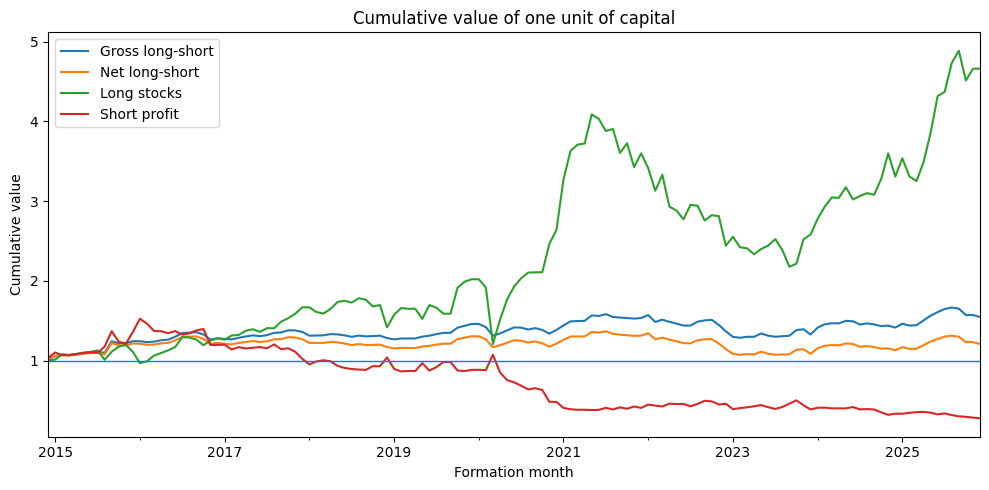

In [24]:
cumulative = pd.DataFrame(index=monthly_returns.index)
cumulative["Gross long-short"] = (1 + monthly_returns["gross_return"]).cumprod()
cumulative["Net long-short"] = (1 + monthly_returns["net_return"]).cumprod()
cumulative["Long stocks"] = (1 + monthly_returns["long_stock_return"]).cumprod()
cumulative["Short profit"] = (1 + monthly_returns["short_profit"]).cumprod()

fig, ax = plt.subplots(figsize=(10, 5))
cumulative.plot(ax=ax)
ax.set_title("Cumulative value of one unit of capital")
ax.set_xlabel("Formation month")
ax.set_ylabel("Cumulative value")
ax.axhline(1, linewidth=1)
plt.tight_layout()
plt.show()

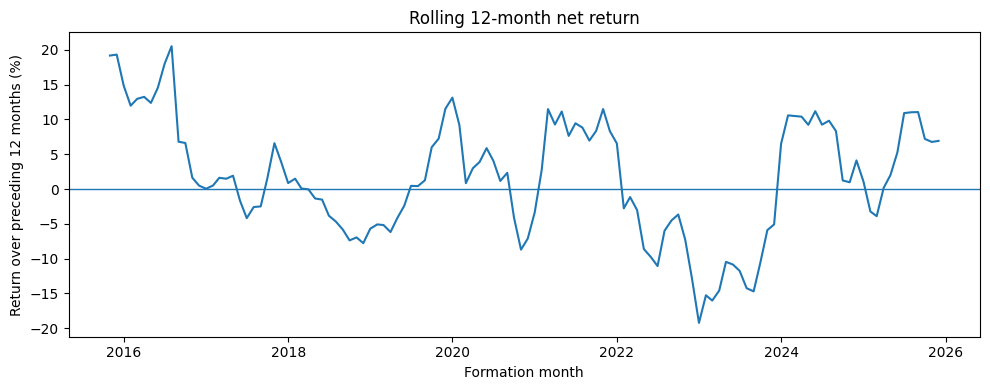

In [25]:
rolling_12m = monthly_returns["net_return"].rolling(12).apply(
    lambda values: np.prod(1 + values) - 1,
    raw=True,
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(rolling_12m.index, rolling_12m * 100)
ax.axhline(0, linewidth=1)
ax.set_title("Rolling 12-month net return")
ax.set_xlabel("Formation month")
ax.set_ylabel("Return over preceding 12 months (%)")
plt.tight_layout()
plt.show()

## 9. Stability through time

The sample is split at its chronological midpoint. This is a descriptive stability check, not a newly tuned train/test procedure.

In [26]:
midpoint = monthly_returns.index[len(monthly_returns) // 2]
period_returns = {
    f"First period: through {midpoint.date()}": monthly_returns.loc[
        monthly_returns.index <= midpoint, "net_return"
    ],
    f"Second period: after {midpoint.date()}": monthly_returns.loc[
        monthly_returns.index > midpoint, "net_return"
    ],
}

subperiod_table = pd.DataFrame({
    label: performance_statistics(values)
    for label, values in period_returns.items()
}).T

display(
    subperiod_table.style.format({
        **{column: "{:.2%}" for column in percentage_columns if column in subperiod_table.columns},
        "Sharpe ratio": "{:.2f}",
        "Months": "{:.0f}",
    })
)

,Months,Mean monthly return,Annualized return,Annualized volatility,Sharpe ratio,Maximum drawdown,Positive months,Average turnover
First period: through 2020-06-01,67,0.37%,4.18%,8.67%,0.51,-11.53%,59.70%,nan%
Second period: after 2020-06-01,66,-0.02%,-0.67%,9.14%,-0.03,-21.58%,48.48%,nan%


## 9A. Uptrend versus downtrend evaluation

This section asks whether the **unchanged** strategy behaved differently under positive and negative market trends.

- The market proxy is the equal-weighted one-month return of all eligible stocks in the research panel.
- A formation month is an **uptrend** when the market proxy's compounded return over the preceding 12 months is positive; otherwise it is a **downtrend**.
- The market return earned during the current holding month is excluded with `shift(1)`, so the regime label uses only information available at formation.
- The portfolio is not retuned within either regime. We compare the same strategy's gross return, net return, long leg, short leg and turnover.
- A paired moving-block bootstrap gives a confidence interval for the difference between mean uptrend and downtrend net returns.

This is a diagnostic regime comparison. Choosing to trade only in one regime after seeing these results would be a new strategy rule and would require later out-of-sample validation.

,Months,Mean gross return,Mean net return,Net annualized volatility,Net Sharpe ratio,Positive net months,Mean long-stock return,Mean short profit,Average turnover
Uptrend,88,0.18%,-0.00%,8.13%,-0.00,52.27%,0.70%,-0.33%,186.18%
Downtrend,33,0.34%,0.16%,8.52%,0.22,54.55%,3.39%,-2.71%,181.54%


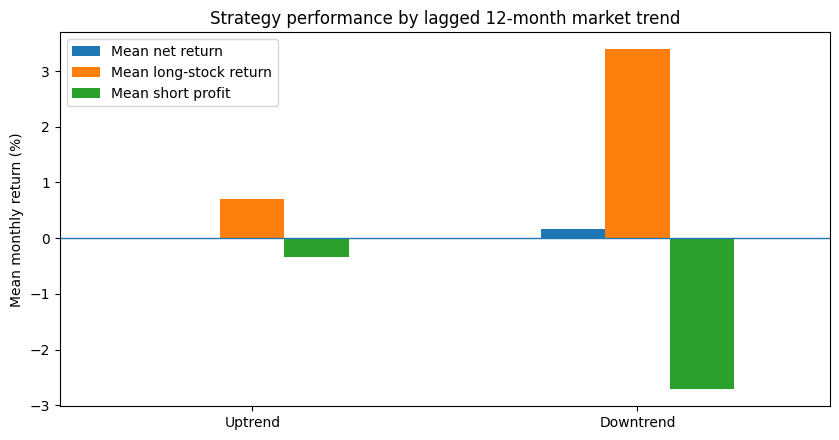

,Comparison,Observed difference,2.5% bootstrap bound,97.5% bootstrap bound,Bootstrap samples
0,Uptrend mean net return minus downtrend mean net return,-0.16%,-1.36%,0.93%,1000


Regime history: 2015-12-01 to 2025-12-01
Observed uptrend-minus-downtrend mean net return: -0.16% per month
95% paired block-bootstrap interval: [-1.36%, 0.93%]


The bootstrap interval includes zero, so the observed difference between uptrend and downtrend performance is not estimated precisely enough to support a regime-filtered trading rule.

In [27]:
# Equal-weighted return across all eligible stocks: a simple market proxy.
market_proxy = (
    panel.groupby("AS_OF")["fwd_1m"]
    .mean()
    .reindex(monthly_returns.index)
    .rename("market_return")
)

regime_returns = monthly_returns.join(market_proxy, how="left")

# At formation month t, use market returns ending at t-1. Because market_return
# indexed by t is earned from t to t+1, shift(1) prevents look-ahead bias.
regime_returns["trailing_12m_market_return"] = (
    (1 + regime_returns["market_return"].shift(1))
    .rolling(12, min_periods=12)
    .apply(np.prod, raw=True)
    - 1
)

regime_returns["trend_regime"] = np.where(
    regime_returns["trailing_12m_market_return"] > 0,
    "Uptrend",
    "Downtrend",
)
regime_returns.loc[
    regime_returns["trailing_12m_market_return"].isna(), "trend_regime"
] = pd.NA

# The first 12 formation months have insufficient prior history and are excluded.
regime_returns = regime_returns.dropna(subset=["trend_regime"]).copy()
regime_returns["trend_regime"] = pd.Categorical(
    regime_returns["trend_regime"],
    categories=["Uptrend", "Downtrend"],
    ordered=True,
)

assert not regime_returns.empty
assert regime_returns.index.is_monotonic_increasing
assert regime_returns["trend_regime"].notna().all()
assert set(regime_returns["trend_regime"].astype(str).unique()).issubset(
    {"Uptrend", "Downtrend"}
)


def summarize_regime(frame):
    net_volatility = frame["net_return"].std(ddof=1)
    net_sharpe = (
        np.nan
        if net_volatility == 0 or np.isnan(net_volatility)
        else frame["net_return"].mean() / net_volatility * np.sqrt(12)
    )
    return pd.Series({
        "Months": len(frame),
        "Mean gross return": frame["gross_return"].mean(),
        "Mean net return": frame["net_return"].mean(),
        "Net annualized volatility": net_volatility * np.sqrt(12),
        "Net Sharpe ratio": net_sharpe,
        "Positive net months": (frame["net_return"] > 0).mean(),
        "Mean long-stock return": frame["long_stock_return"].mean(),
        "Mean short profit": frame["short_profit"].mean(),
        "Average turnover": frame["turnover"].mean(),
    })


regime_summary = pd.DataFrame({
    regime: summarize_regime(group)
    for regime, group in regime_returns.groupby("trend_regime", observed=True)
}).T.reindex(["Uptrend", "Downtrend"])

regime_percentage_columns = [
    "Mean gross return",
    "Mean net return",
    "Net annualized volatility",
    "Positive net months",
    "Mean long-stock return",
    "Mean short profit",
    "Average turnover",
]

display(
    regime_summary.style.format({
        **{column: "{:.2%}" for column in regime_percentage_columns},
        "Net Sharpe ratio": "{:.2f}",
        "Months": "{:.0f}",
    })
)

# One compact visual comparison. Long and short legs are normalized as standalone
# leg returns in the main portfolio section, while net return includes costs.
regime_plot = regime_summary[[
    "Mean net return",
    "Mean long-stock return",
    "Mean short profit",
]] * 100

ax = regime_plot.plot(kind="bar", figsize=(8.5, 4.5))
ax.axhline(0, linewidth=1)
ax.set_title("Strategy performance by lagged 12-month market trend")
ax.set_xlabel("")
ax.set_ylabel("Mean monthly return (%)")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()


def regime_difference_block_bootstrap(
    data,
    block_length,
    n_bootstraps,
    random_seed,
):
    """Bootstrap the uptrend-minus-downtrend difference using paired time blocks."""
    base = data[["net_return", "trend_regime"]].dropna().copy()
    returns = base["net_return"].to_numpy(dtype=float)
    regimes = base["trend_regime"].astype(str).to_numpy()
    n = len(base)

    if n < block_length:
        raise ValueError("The bootstrap block is longer than the regime history.")

    rng = np.random.default_rng(random_seed)
    differences = np.full(n_bootstraps, np.nan)

    for bootstrap_index in range(n_bootstraps):
        sampled_indices = []
        while len(sampled_indices) < n:
            start = rng.integers(0, n - block_length + 1)
            sampled_indices.extend(range(start, start + block_length))
        sampled_indices = np.asarray(sampled_indices[:n])

        sampled_returns = returns[sampled_indices]
        sampled_regimes = regimes[sampled_indices]
        uptrend_returns = sampled_returns[sampled_regimes == "Uptrend"]
        downtrend_returns = sampled_returns[sampled_regimes == "Downtrend"]

        if len(uptrend_returns) > 0 and len(downtrend_returns) > 0:
            differences[bootstrap_index] = (
                uptrend_returns.mean() - downtrend_returns.mean()
            )

    differences = differences[np.isfinite(differences)]
    if len(differences) == 0:
        raise ValueError("No bootstrap sample contained both regimes.")
    return differences


observed_regime_difference = (
    regime_returns.loc[
        regime_returns["trend_regime"] == "Uptrend", "net_return"
    ].mean()
    - regime_returns.loc[
        regime_returns["trend_regime"] == "Downtrend", "net_return"
    ].mean()
)

regime_bootstrap_differences = regime_difference_block_bootstrap(
    regime_returns,
    block_length=BOOTSTRAP_BLOCK_MONTHS,
    n_bootstraps=N_BOOTSTRAPS,
    random_seed=RANDOM_SEED,
)

regime_ci_lower, regime_ci_upper = np.quantile(
    regime_bootstrap_differences, [0.025, 0.975]
)

regime_bootstrap_summary = pd.DataFrame({
    "Comparison": ["Uptrend mean net return minus downtrend mean net return"],
    "Observed difference": [observed_regime_difference],
    "2.5% bootstrap bound": [regime_ci_lower],
    "97.5% bootstrap bound": [regime_ci_upper],
    "Bootstrap samples": [len(regime_bootstrap_differences)],
})

display(
    regime_bootstrap_summary.style.format({
        "Observed difference": "{:.2%}",
        "2.5% bootstrap bound": "{:.2%}",
        "97.5% bootstrap bound": "{:.2%}",
        "Bootstrap samples": "{:.0f}",
    })
)

if regime_ci_lower > 0:
    regime_interpretation = (
        "The bootstrap interval is entirely above zero, so the strategy's mean "
        "net return was higher in uptrends in this sample. This remains an "
        "in-sample diagnostic rather than proof that an uptrend-only filter will "
        "work out of sample."
    )
elif regime_ci_upper < 0:
    regime_interpretation = (
        "The bootstrap interval is entirely below zero, so the strategy's mean "
        "net return was higher in downtrends in this sample. This remains an "
        "in-sample diagnostic rather than proof that a downtrend-only filter will "
        "work out of sample."
    )
else:
    regime_interpretation = (
        "The bootstrap interval includes zero, so the observed difference between "
        "uptrend and downtrend performance is not estimated precisely enough to "
        "support a regime-filtered trading rule."
    )

print(
    f"Regime history: {regime_returns.index.min().date()} to "
    f"{regime_returns.index.max().date()}"
)
print(
    "Observed uptrend-minus-downtrend mean net return: "
    f"{observed_regime_difference:.2%} per month"
)
print(
    "95% paired block-bootstrap interval: "
    f"[{regime_ci_lower:.2%}, {regime_ci_upper:.2%}]"
)
display(Markdown(regime_interpretation))

## 10. Return-shuffling test

The portfolio weights and selected stocks are held fixed. Within each month and sector, the subsequent stock returns are randomly reassigned across eligible stocks. This preserves the market environment and cross-sectional return distribution but destroys the relationship between the signal and the stock that earned each return.

A useful signal should outperform most of these shuffled alternatives. This is not because a strategy must lose on random data; it is because the shuffled tests represent outcomes in which the signal-stock link has been deliberately removed.

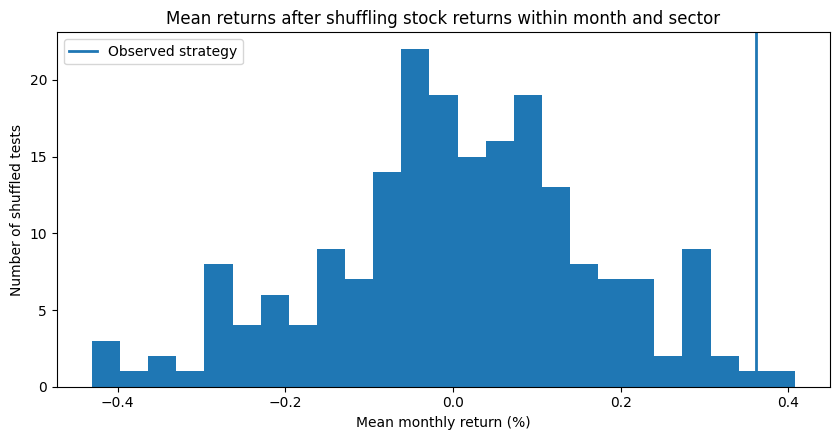

Observed gross mean monthly return: 0.36%
Average shuffled mean monthly return: 0.00%
One-sided permutation p-value: 0.010


In [28]:
permutation_base = combined.copy().reset_index(drop=True)
weight_lookup = portfolio.set_index(["AS_OF", "sector", "IQID"])["weight"]
permutation_base["weight"] = [
    weight_lookup.get((row.AS_OF, row.sector, row.IQID), 0.0)
    for row in permutation_base.itertuples()
]

month_values = np.asarray(all_months)
month_codes_lookup = {month: position for position, month in enumerate(month_values)}
permutation_base["month_code"] = permutation_base["AS_OF"].map(month_codes_lookup).astype(int)

group_indices = list(
    permutation_base.groupby(["AS_OF", "sector"], sort=False).indices.values()
)
observed_returns = permutation_base["fwd_1m"].to_numpy()
portfolio_weights = permutation_base["weight"].to_numpy()
month_codes = permutation_base["month_code"].to_numpy()

rng = np.random.default_rng(RANDOM_SEED)
permuted_mean_returns = []

for _ in range(N_PERMUTATIONS):
    shuffled_returns = observed_returns.copy()
    for indices in group_indices:
        shuffled_returns[indices] = rng.permutation(shuffled_returns[indices])

    shuffled_monthly_return = np.bincount(
        month_codes,
        weights=portfolio_weights * shuffled_returns,
        minlength=len(month_values),
    )
    permuted_mean_returns.append(shuffled_monthly_return.mean())

permuted_mean_returns = np.asarray(permuted_mean_returns)
observed_mean_return = monthly_returns["gross_return"].mean()
permutation_p_value = (
    1 + np.sum(permuted_mean_returns >= observed_mean_return)
) / (N_PERMUTATIONS + 1)

fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.hist(permuted_mean_returns * 100, bins=25)
ax.axvline(observed_mean_return * 100, linewidth=2, label="Observed strategy")
ax.set_title("Mean returns after shuffling stock returns within month and sector")
ax.set_xlabel("Mean monthly return (%)")
ax.set_ylabel("Number of shuffled tests")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Observed gross mean monthly return: {observed_mean_return:.2%}")
print(f"Average shuffled mean monthly return: {permuted_mean_returns.mean():.2%}")
print(f"One-sided permutation p-value: {permutation_p_value:.3f}")

## 11. Block bootstrap

Months are resampled in six-month blocks. Keeping neighbouring months together retains some persistence in market conditions and shows how uncertain the estimated mean return and Sharpe ratio are across alternative histories drawn from the same sample.

In [29]:
def moving_block_bootstrap(returns, block_length, n_bootstraps, random_seed):
    values = np.asarray(returns, dtype=float)
    n = len(values)
    if n < block_length:
        raise ValueError("The bootstrap block is longer than the return history.")

    rng = np.random.default_rng(random_seed)
    means = np.empty(n_bootstraps)
    sharpes = np.empty(n_bootstraps)

    for bootstrap_index in range(n_bootstraps):
        sample = []
        while len(sample) < n:
            start = rng.integers(0, n - block_length + 1)
            sample.extend(values[start : start + block_length])
        sample = np.asarray(sample[:n])

        means[bootstrap_index] = sample.mean()
        sample_volatility = sample.std(ddof=1)
        sharpes[bootstrap_index] = (
            np.nan
            if sample_volatility == 0
            else sample.mean() / sample_volatility * np.sqrt(12)
        )

    return means, sharpes

bootstrap_means, bootstrap_sharpes = moving_block_bootstrap(
    monthly_returns["net_return"],
    block_length=BOOTSTRAP_BLOCK_MONTHS,
    n_bootstraps=N_BOOTSTRAPS,
    random_seed=RANDOM_SEED,
)

bootstrap_summary = pd.DataFrame({
    "Statistic": ["Mean monthly net return", "Annualized net Sharpe ratio"],
    "Observed": [
        monthly_returns["net_return"].mean(),
        performance_table.loc["Net long-short", "Sharpe ratio"],
    ],
    "2.5% bootstrap bound": [
        np.nanquantile(bootstrap_means, 0.025),
        np.nanquantile(bootstrap_sharpes, 0.025),
    ],
    "97.5% bootstrap bound": [
        np.nanquantile(bootstrap_means, 0.975),
        np.nanquantile(bootstrap_sharpes, 0.975),
    ],
})

display(
    bootstrap_summary.style.format({
        "Observed": "{:.3f}",
        "2.5% bootstrap bound": "{:.3f}",
        "97.5% bootstrap bound": "{:.3f}",
    })
)

,Statistic,Observed,2.5% bootstrap bound,97.5% bootstrap bound
0,Mean monthly net return,0.002,-0.003,0.006
1,Annualized net Sharpe ratio,0.238,-0.389,0.813


## 12. Results summary

The following summary is generated from the current database. When using the sample database, treat it only as a methodology check. Rerun the notebook against the full database before using the numbers in an interview.

In [30]:
net_stats = performance_table.loc["Net long-short"]
active_month_share = (monthly_returns["positions"] > 0).mean()

summary_text = f"""
### Current-database findings

- The EPS-only top-minus-bottom decile spread is **{monthly_spread.mean():.2%} per month**.
- The sector-neutral disagreement portfolio has a gross mean return of **{monthly_returns['gross_return'].mean():.2%} per month** and a net mean return of **{monthly_returns['net_return'].mean():.2%}** after the stated cost assumption.
- Its net annualized Sharpe ratio is **{net_stats['Sharpe ratio']:.2f}**, with a maximum drawdown of **{net_stats['Maximum drawdown']:.2%}**.
- A valid portfolio is active in **{active_month_share:.1%}** of research months.
- The return-shuffling p-value is **{permutation_p_value:.3f}**.
- The 95% block-bootstrap interval for the mean monthly net return is **[{np.quantile(bootstrap_means, 0.025):.2%}, {np.quantile(bootstrap_means, 0.975):.2%}]**.

These statistics should be judged together. Attractive average returns are less convincing if they are concentrated in one subperiod, depend mainly on one side of the portfolio, have a wide bootstrap interval, or are not unusual relative to shuffled returns.
"""

display(Markdown(summary_text))


### Current-database findings

- The EPS-only top-minus-bottom decile spread is **0.92% per month**.
- The sector-neutral disagreement portfolio has a gross mean return of **0.36% per month** and a net mean return of **0.18%** after the stated cost assumption.
- Its net annualized Sharpe ratio is **0.24**, with a maximum drawdown of **-21.58%**.
- A valid portfolio is active in **97.7%** of research months.
- The return-shuffling p-value is **0.010**.
- The 95% block-bootstrap interval for the mean monthly net return is **[-0.27%, 0.60%]**.

These statistics should be judged together. Attractive average returns are less convincing if they are concentrated in one subperiod, depend mainly on one side of the portfolio, have a wide bootstrap interval, or are not unusual relative to shuffled returns.


## 13. Export the readable results

The files below make it easy to inspect or present the main outputs after the full-database run.

In [20]:
OUTPUT_DIRECTORY = Path("signal_validation_outputs")
OUTPUT_DIRECTORY.mkdir(exist_ok=True)

performance_table.to_csv(OUTPUT_DIRECTORY / "performance_summary.csv")
monthly_returns.to_csv(OUTPUT_DIRECTORY / "monthly_returns.csv")
portfolio.to_csv(OUTPUT_DIRECTORY / "portfolio_holdings.csv", index=False)
eps_decile_returns.rename("mean_return").to_csv(
    OUTPUT_DIRECTORY / "eps_decile_returns.csv"
)
heatmap.to_csv(OUTPUT_DIRECTORY / "eps_sentiment_heatmap.csv")
bootstrap_summary.to_csv(OUTPUT_DIRECTORY / "bootstrap_summary.csv", index=False)

print(f"Results exported to: {OUTPUT_DIRECTORY.resolve()}")
regime_summary.to_csv(OUTPUT_DIRECTORY / "trend_regime_summary.csv")
regime_bootstrap_summary.to_csv(
    OUTPUT_DIRECTORY / "trend_regime_bootstrap_summary.csv", index=False
)
regime_returns.to_csv(OUTPUT_DIRECTORY / "monthly_returns_with_trend_regime.csv")

Results exported to: C:\Users\adamf\PycharmProjects\FedContracts_AlgoTrading\signal_validation_outputs


## Final interpretation framework

The project should not be described as successful solely because one cumulative-return line rises. A defensible conclusion should answer four questions:

1. **Economic pattern:** Do higher EPS-revision groups generally earn higher subsequent returns, and is the high-EPS/negative-sentiment corner especially strong?
2. **Implementation:** Does the pattern survive explicit monthly timing, sector neutrality, turnover and costs?
3. **Stability:** Are the first and second halves reasonably consistent, and do both portfolio legs contribute?
4. **Uncertainty:** Is the real result unusual relative to shuffled returns, and how wide is the bootstrap interval?

A negative or inconclusive answer is still a useful research result. It shows that an economically plausible exploratory pattern did not survive a more disciplined implementation.